In [75]:
from konlpy.tag import Kkma
from konlpy.utils import pprint

In [76]:
corpus="구글은 인공지능(AI) 모델 제미나이와 클라우드 서비스 제품군을 미국 연방 정부 기관에 각각 연 0.47달러의 가격으로 제공한다고 21일(현지시간)밝혔다. 이에 따라 연방 정부 기관들은 저렴한 가격으로 내년까지 '정부용제미나이'(Gemini for Goverment)를 이용할 수 있게 된다. 이달 초 구글 제미나이, 오픈AI 챗GPT, 앤스로픽의 클로드"
corpus.split('. ')

['구글은 인공지능(AI) 모델 제미나이와 클라우드 서비스 제품군을 미국 연방 정부 기관에 각각 연 0.47달러의 가격으로 제공한다고 21일(현지시간)밝혔다',
 "이에 따라 연방 정부 기관들은 저렴한 가격으로 내년까지 '정부용제미나이'(Gemini for Goverment)를 이용할 수 있게 된다",
 '이달 초 구글 제미나이, 오픈AI 챗GPT, 앤스로픽의 클로드']

In [77]:
import re
re.split(r'[.,] ',corpus)

['구글은 인공지능(AI) 모델 제미나이와 클라우드 서비스 제품군을 미국 연방 정부 기관에 각각 연 0.47달러의 가격으로 제공한다고 21일(현지시간)밝혔다',
 "이에 따라 연방 정부 기관들은 저렴한 가격으로 내년까지 '정부용제미나이'(Gemini for Goverment)를 이용할 수 있게 된다",
 '이달 초 구글 제미나이',
 '오픈AI 챗GPT',
 '앤스로픽의 클로드']

In [78]:
from konlpy.tag import Okt

okt=Okt()
#형태소 분리
print(okt.morphs(corpus))

['구글', '은', '인공', '지능', '(', 'AI', ')', '모델', '제', '미나', '이', '와', '클라우드', '서비스', '제품군', '을', '미국', '연방', '정부', '기관', '에', '각각', '연', '0.47달러', '의', '가격', '으로', '제공', '한', '다', '고', '21일', '(', '현지', '시간', ')', '밝혔다', '.', '이', '에', '따라', '연방', '정부', '기관', '들', '은', '저렴한', '가격', '으로', '내년', '까지', "'", '정부', '용제', '미나', '이', "'(", 'Gemini', 'for', 'Goverment', ')', '를', '이용', '할', '수', '있게', '된다', '.', '이', '달', '초', '구글', '제', '미나', '이', ',', '오픈', 'AI', '챗', 'GPT', ',', '앤스로픽', '의', '클로드']


In [79]:
#형태소 분리 후 명사만 추출
print(okt.nouns(corpus))

['구글', '인공', '지능', '모델', '미나', '클라우드', '서비스', '제품군', '미국', '연방', '정부', '기관', '각각', '연', '가격', '제공', '고', '현지', '시간', '이', '연방', '정부', '기관', '가격', '내년', '정부', '용제', '미나', '를', '이용', '수', '달', '초', '구글', '미나', '오픈', '챗', '앤스로픽', '클로드']


In [80]:
import re

# 텍스트 정제를 위한 함수 정의
def cleanString(text):

    # E-mail 주소 제거
    # ^ : 문자열의 시작
    # [a-z0-9_.+-]+ : 문자(a-z), 숫자(0-9), 언더바(_), 점(.), 플러스(+), 하이픈(-)
    # @ : '@' 기호
    # [a-z0-9-]+ : 문자(a-z), 숫자(0-9), 하이픈(-)
    # \. : 점(.)
    # [a-z]{2,6} : 소문자 a-z와 점(.)으로 구성된 문자 2~6개
    # $ : 문자열의 끝
    pattern = r'^([a-z0-9_.+-]+)@([a-z0-9-]+)\.([a-z.]{2,6})$'
    text = re.sub(pattern=pattern, repl='', string=text)

    # 한글 자음, 모음 제거
    # [ㄱ-ㅎㅏ-ㅣ]+ : 자음 또는 모음이 1개 이상 반복
    pattern = r'[ㄱ-ㅎㅏ-ㅣ]+'
    text = re.sub(pattern=pattern, repl='', string=text)

    # HTML 태그 제거
    # <.*?> : <로 시작하고 >로 끝나는 모든 문자열
    pattern = r'<.*?>'
    text = re.sub(pattern=pattern, repl='', string=text)

    # 특수문자 제거
    # [^\w\s\n] : 영문 대소문자, 숫자, 개행문자가 아닌 문자
    pattern = r'[^\w\s\n]'
    text = re.sub(pattern=pattern, repl='', string=text)

    return text


# 텍스트 정제
cleanString(corpus)


'구글은 인공지능AI 모델 제미나이와 클라우드 서비스 제품군을 미국 연방 정부 기관에 각각 연 047달러의 가격으로 제공한다고 21일현지시간밝혔다 이에 따라 연방 정부 기관들은 저렴한 가격으로 내년까지 정부용제미나이Gemini for Goverment를 이용할 수 있게 된다 이달 초 구글 제미나이 오픈AI 챗GPT 앤스로픽의 클로드'

In [81]:
stop_str = [
    "이", "그", "저", "것", "수", "등", "및", "또는",
    "그리고", "하지만", "그러나", "그래서", "즉",
    "에", "에서", "에게", "께", "으로", "로", "와", "과",
    "도", "만", "까지", "부터", "보다", "처럼", "같이",
    "의", "은", "는", "이", "가", "을", "를",
    "하다", "되다", "있다", "없다", "이다","있게",
    "이다", "입니다", "했다", "하였다", "한다",
    "하는", "한", "할",
    "때", "경우", "관련", "대해", "대한",
    "등등", "등의", "등을",'된다',
    "더", "가장", "매우", "아주", "정말",
    "좀", "약간", "다소",
    "같은", "이런", "저런", "그런",
    "여기", "저기", "거기",
    "이미", "아직", "다시",
    "또", "계속", "항상", "보통",
    "왜", "어떻게", "무엇", "어디", "언제",
    "누가", "누구",
]

stop_words=set(stop_str)
corpus_cleaned=cleanString(corpus)
words_morphs=okt.morphs(corpus_cleaned)
words=[word for word in words_morphs if word not in stop_words]
print(words)

['구글', '인공', '지능', 'AI', '모델', '제', '미나', '클라우드', '서비스', '제품군', '미국', '연방', '정부', '기관', '각각', '연', '047달러', '가격', '제공', '다', '고', '21일', '현지시간밝혔다', '따라', '연방', '정부', '기관', '들', '저렴한', '가격', '내년', '정부', '용제', '미나', 'Gemini', 'for', 'Goverment', '이용', '달', '초', '구글', '제', '미나', '오픈', 'AI', '챗', 'GPT', '앤스로픽', '클로드']


In [82]:
#품사태깅
okt.tagset

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [83]:
print(okt.pos(corpus)) #형태소 분리 후 품사 태깅

[('구글', 'Noun'), ('은', 'Josa'), ('인공', 'Noun'), ('지능', 'Noun'), ('(', 'Punctuation'), ('AI', 'Alpha'), (')', 'Punctuation'), ('모델', 'Noun'), ('제', 'Modifier'), ('미나', 'Noun'), ('이', 'Suffix'), ('와', 'Josa'), ('클라우드', 'Noun'), ('서비스', 'Noun'), ('제품군', 'Noun'), ('을', 'Josa'), ('미국', 'Noun'), ('연방', 'Noun'), ('정부', 'Noun'), ('기관', 'Noun'), ('에', 'Josa'), ('각각', 'Noun'), ('연', 'Noun'), ('0.47달러', 'Number'), ('의', 'Foreign'), ('가격', 'Noun'), ('으로', 'Josa'), ('제공', 'Noun'), ('한', 'Josa'), ('다', 'Adverb'), ('고', 'Noun'), ('21일', 'Number'), ('(', 'Punctuation'), ('현지', 'Noun'), ('시간', 'Noun'), (')', 'Punctuation'), ('밝혔다', 'Verb'), ('.', 'Punctuation'), ('이', 'Noun'), ('에', 'Josa'), ('따라', 'Verb'), ('연방', 'Noun'), ('정부', 'Noun'), ('기관', 'Noun'), ('들', 'Suffix'), ('은', 'Josa'), ('저렴한', 'Adjective'), ('가격', 'Noun'), ('으로', 'Josa'), ('내년', 'Noun'), ('까지', 'Josa'), ("'", 'Punctuation'), ('정부', 'Noun'), ('용제', 'Noun'), ('미나', 'Noun'), ('이', 'Suffix'), ("'(", 'Punctuation'), ('Gemini', 'Alpha'), ('f

In [84]:
corpus_pos=okt.pos(corpus)
words=[word for word, pos in corpus_pos if pos in ['Noun','Verb','Adjective']]
print(words)

['구글', '인공', '지능', '모델', '미나', '클라우드', '서비스', '제품군', '미국', '연방', '정부', '기관', '각각', '연', '가격', '제공', '고', '현지', '시간', '밝혔다', '이', '따라', '연방', '정부', '기관', '저렴한', '가격', '내년', '정부', '용제', '미나', '를', '이용', '할', '수', '있게', '된다', '달', '초', '구글', '미나', '오픈', '챗', '앤스로픽', '클로드']


In [85]:
from ckonlpy.tag import Twitter
okt=Okt()
twitter=Twitter()

twitter.add_dictionary(['제미나이','오픈AI','챗GPT','앤스로픽','클로드'],'Noun')

print(f'{okt.nouns(corpus)=}')
print(f'{twitter.nouns(corpus)=}')

c:\Users\paint\anaconda3\envs\konrpy\Lib\site-packages\konlpy\tag\_okt.py:17: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


okt.nouns(corpus)=['구글', '인공', '지능', '모델', '미나', '클라우드', '서비스', '제품군', '미국', '연방', '정부', '기관', '각각', '연', '가격', '제공', '고', '현지', '시간', '이', '연방', '정부', '기관', '가격', '내년', '정부', '용제', '미나', '를', '이용', '수', '달', '초', '구글', '미나', '오픈', '챗', '앤스로픽', '클로드']
twitter.nouns(corpus)=['구글', '인공', '지능', '모델', '제미나이', '클라우드', '서비스', '제품군', '미국', '연방', '정부', '기관', '각각', '연', '달러', '가격', '제공', '현지', '시간', '이', '연방', '정부', '기관', '저렴', '가격', '내년', '까지', '정', '부용', '제미나이', '를', '이용', '수', '달', '초', '구글', '제미나이', '오픈AI', '챗GPT', '앤스로픽', '클로드']


In [ ]:
#최빈단어 검색
from collections import Counter
token_list=twitter.nouns(corpus)
vocab=Counter(token_list)
print(vocab)

Counter({'제미나이': 3, '구글': 2, '연방': 2, '정부': 2, '기관': 2, '가격': 2, '인공': 1, '지능': 1, '모델': 1, '클라우드': 1, '서비스': 1, '제품군': 1, '미국': 1, '각각': 1, '연': 1, '달러': 1, '제공': 1, '현지': 1, '시간': 1, '이': 1, '저렴': 1, '내년': 1, '까지': 1, '정': 1, '부용': 1, '를': 1, '이용': 1, '수': 1, '달': 1, '초': 1, '오픈AI': 1, '챗GPT': 1, '앤스로픽': 1, '클로드': 1})


In [ ]:
vocab_most_frequent=vocab.most_common(5)
print(vocab_most_frequent)
vocab_dict={word:(idx+1) for idx,(word,_) in enumerate(vocab.most_common())}
print(vocab_dict)

[('제미나이', 3), ('구글', 2), ('연방', 2), ('정부', 2), ('기관', 2)]
{'제미나이': 1, '구글': 2, '연방': 3, '정부': 4, '기관': 5, '가격': 6, '인공': 7, '지능': 8, '모델': 9, '클라우드': 10, '서비스': 11, '제품군': 12, '미국': 13, '각각': 14, '연': 15, '달러': 16, '제공': 17, '현지': 18, '시간': 19, '이': 20, '저렴': 21, '내년': 22, '까지': 23, '정': 24, '부용': 25, '를': 26, '이용': 27, '수': 28, '달': 29, '초': 30, '오픈AI': 31, '챗GPT': 32, '앤스로픽': 33, '클로드': 34}


In [ ]:
import numpy as np
token_coded = [vocab_dict[word] for word in token_list]
print(token_coded)

[2, 7, 8, 9, 1, 10, 11, 12, 13, 3, 4, 5, 14, 15, 16, 6, 17, 18, 19, 20, 3, 4, 5, 21, 6, 22, 23, 24, 25, 1, 26, 27, 28, 29, 30, 2, 1, 31, 32, 33, 34]


In [ ]:
#패딩
#서로 길이가 다른 문장 병렬 연산 위해서 데이터 크기를 조정하는 것

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# 단어별 출현 빈도수를 비율로 반환하는 객체를 생성
words_kor=WordCloud().generate(corpus)
print(words_kor.words_)

{'연방': 1.0, '정부': 1.0, '가격으로': 1.0, '구글은': 0.5, '인공지능': 0.5, 'AI': 0.5, '모델': 0.5, '제미나이와': 0.5, '클라우드': 0.5, '서비스': 0.5, '제품군을': 0.5, '미국': 0.5, '기관에': 0.5, '각각': 0.5, '연': 0.5, '47달러의': 0.5, '제공한다고': 0.5, '21일': 0.5, '현지시간': 0.5, '밝혔다': 0.5, '이에': 0.5, '따라': 0.5, '기관들은': 0.5, '저렴한': 0.5, '내년까지': 0.5, "정부용제미나이'": 0.5, 'Gemini': 0.5, 'Goverment': 0.5, '를': 0.5, '이용할': 0.5, '수': 0.5, '있게': 0.5, '된다': 0.5, '이달': 0.5, '초': 0.5, '구글': 0.5, '제미나이': 0.5, '오픈AI': 0.5, '챗GPT': 0.5, '앤스로픽의': 0.5, '클로드': 0.5}


In [103]:
from matplotlib import font_manager
font_manager.findfont('SB')

'C:\\Users\\paint\\anaconda3\\envs\\konrpy\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf'

In [107]:
font_manager.findSystemFonts()[:10]

['C:\\Windows\\Fonts\\corbelli.ttf',
 'C:\\Windows\\Fonts\\HANDotum.ttf',
 'C:\\Windows\\Fonts\\BROADW.TTF',
 'C:\\Windows\\Fonts\\BAUHS93.TTF',
 'C:\\Windows\\Fonts\\VINERITC.TTF',
 'C:\\Windows\\Fonts\\GOTHICI.TTF',
 'C:\\Users\\paint\\AppData\\Local\\Microsoft\\Windows\\Fonts\\The Jamsil OTF 4 Medium.otf',
 'C:\\Windows\\Fonts\\consolai.ttf',
 'C:\\Windows\\Fonts\\PERTIBD.TTF',
 'C:\\Windows\\Fonts\\ROCK.TTF']

In [104]:
#한글 폰트 경로 직접 지정
pont_path='C:\\Users\\paint\\anaconda3\\envs\\konrpy\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf'

In [111]:
han_font_path='C:\\Users\\paint\\AppData\\Local\\Microsoft\\Windows\\Fonts\\The Jamsil OTF 4 Medium.otf'

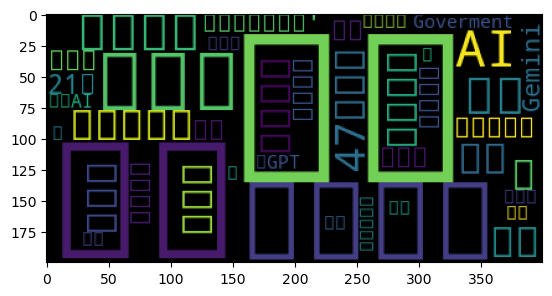

In [98]:
plt.imshow(words_kor)

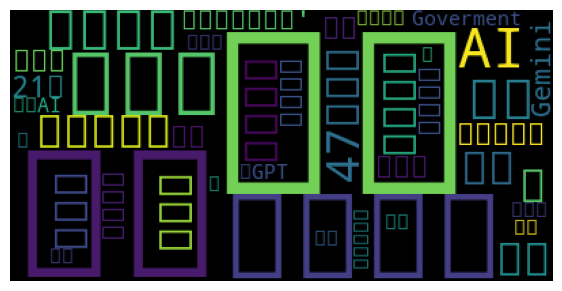

In [ ]:
def showwordCloudBasic(wc):
    plt.figure(figsize=(7,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

showwordCloudBasic(words_kor)

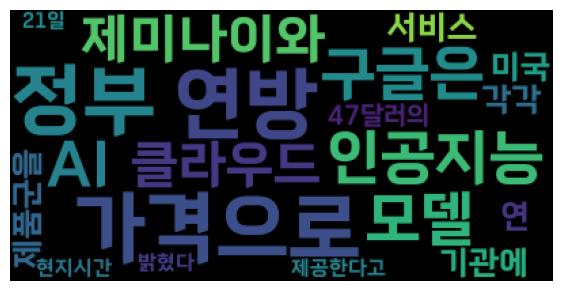

In [112]:
words_kor = WordCloud(
    max_words=20, #최대 표시 단어 수
    font_path=han_font_path
).generate(corpus)
showwordCloudBasic(words_kor)

In [ ]:
#wordcloud에서 제공하는 영어 불용어
from wordcloud import STOPWORDS
print(STOPWORDS)
print(type(STOPWORDS))
#불용어 목록에 단어 한 개 추가
STOPWORDS.add('words')
#여러개 추가
STOPWORDS.update(['cloud','text','data'])

{'other', 'off', 'and', "we've", 'are', 'you', "they're", 'up', "isn't", 'same', 'hence', 'own', 'in', 'where', 'who', "didn't", 'him', "she's", 'until', 'once', "he's", "we'd", 'k', "what's", 'below', 'was', 'to', 'at', 'had', 'get', 'its', 'again', 'do', "we're", 'between', 'is', 'else', 'http', 'of', 'www', 'they', 'about', 'been', "let's", 'com', 'or', 'over', 'then', "can't", 'how', "that's", "haven't", 'therefore', 'out', 'were', 'before', "i'll", 'as', 'can', 'yourselves', 'just', "shouldn't", 'than', 'too', 'if', 'his', 'ever', "he'll", 'ourselves', "where's", 'have', 'for', 'it', 'a', 'while', 'be', "when's", 'above', 'himself', 'whom', 'only', 'so', 'such', "how's", 'what', 'through', 'them', 'with', 'against', 'all', "i'd", 'when', "don't", "it's", 'being', 'each', 'nor', "she'd", 'their', "here's", 'not', 'does', 'also', "he'd", 'cannot', 'very', 'yourself', "wasn't", 'by', 'after', 'both', 'me', 'there', "hasn't", 'however', 'more', 'why', "wouldn't", 'could', "i'm", 'thos

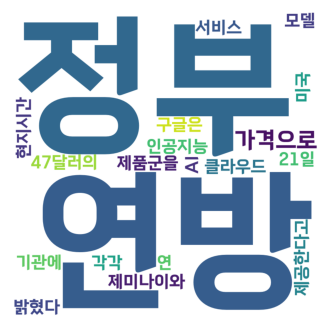

In [113]:
#크기 및 색상 지정
words_kor=WordCloud(
    max_words=20,
    font_path=han_font_path,
    stopwords=stop_words,
    width=800,
    height=800,
    background_color='white',
    colormap='viridis'
).generate(corpus)

showwordCloudBasic(words_kor)

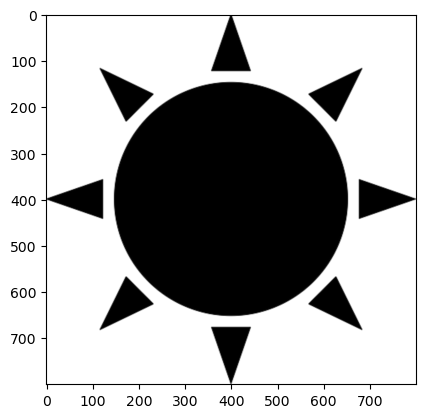

In [137]:
#mask 이미지 적용
from PIL import Image
image=Image.open(
    r'C:\Users\paint\OneDrive\Desktop\Githubproject\Dataviz\데이터 시각화\data\태양.png'
).resize(size=(800,800))
plt.imshow(image)

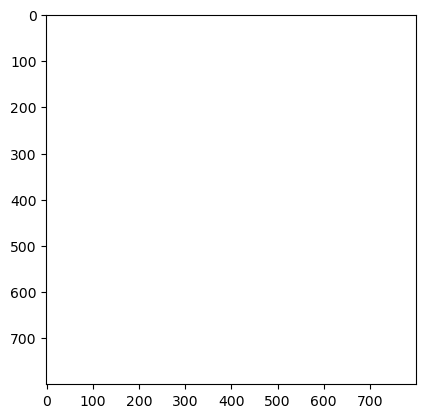

In [138]:
#255,255,255는 rgb, 흰색 배경을 뜻함
wc_mask=Image.new("RGB",image.size,(255,255,255))
plt.imshow(wc_mask);

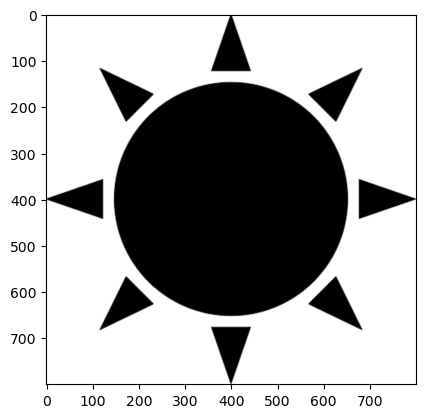

In [139]:
wc_mask.paste(im=image,mask=image)
plt.imshow(wc_mask)

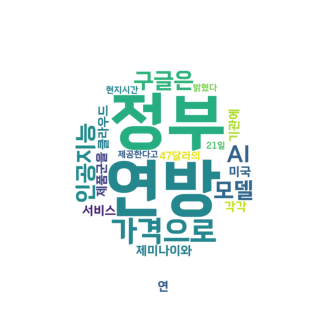

In [140]:
#이미지를 ndarray로 변환
wc_mask= np.array(wc_mask)

words_kor=WordCloud(
    max_words=20,
    font_path=han_font_path,
    stopwords=stop_words,
    mask=wc_mask,
    background_color='white',
    colormap='viridis'
).generate(corpus)

showwordCloudBasic(words_kor)

In [144]:
import pandas as pd
df=pd.read_csv(r"C:\Users\paint\OneDrive\Desktop\Githubproject\Dataviz\lit_practice\naver_news.csv")
df.head()

,pubDate,title,description
0,2025-12-14 21:40:00,정원오 서울시장 출마 선언 임박? “서울을 글로벌 G2 메가시티로 만들...,정원오가 생각하는 ‘서울의 비전’은?서울시장에 출마한다면 공약은?구청장 11년 동안...
1,2025-12-14 21:14:00,[스트레이트] 누구를 위한 사업인가,[이광수/부동산 전문가] &quot;기업이 그렇게 (땅을) 사는 건 흔치 않은 경우...
2,2025-12-14 19:38:00,"오세훈 &quot;정부, 10.15 대책 부작용 외면…규제 완화하라&quot;",&quot;실수요자 투기꾼 취급하는 대출 정책도 즉각 전환해야&quot; 오세훈 서...
3,2025-12-14 19:32:00,오세훈 &quot;10.15 부동산대책은 악정(惡政)&quot;,"&quot;정부, 주거 불안 해소는커녕 오히려 부추긴 꼴&quot; 오세훈 서울시장..."
4,2025-12-14 18:46:00,"[EBN 오늘(14일) 이슈 종합] 재계, 연말 인사 마무리 후 'AI 중심' 내년...",14일 업계에 따르면 주요 부동산 연구기관들은 내년 전국 집값을 보합 내지 소폭 하...


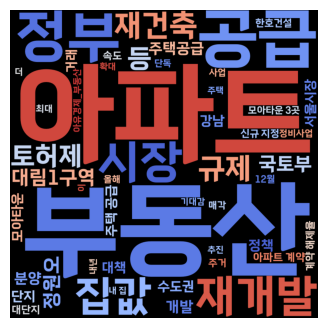

In [149]:
from matplotlib import font_manager
#title 컬럼의 데이터를 하나의 문자열로 합치기
text=' '.join(df['title'].tolist())
stop_str='quot 오세훈 서울시 [스트레이트] 14일 ? 서울 심층분석 주요 즉각'
stop_words=set(stop_str.split(' '))
STOPWORDS.update(stop_words)

words_han=WordCloud(
    font_path=han_font_path,
    max_words=50,
    width=800,
    height=800,
    stopwords=STOPWORDS,
    background_color='black',
    colormap='coolwarm'
).generate(text)
showwordCloudBasic(words_han)